# EcoShield AI - Exploratory Data Analysis

Bu notebook, EcoShield AI projesinde kullanılacak **Credit Card Fraud Detection** veri setinin ilk analizini içerir.

Amaç:
- Veri setinin genel yapısını incelemek
- Fraud / normal işlem dağılımını görmek
- Eksik değer ve tekrar eden satırları kontrol etmek
- `Amount` ve `Time` değişkenlerini analiz etmek
- Sprint 1 için görsel ve metinsel çıktı üretmek

In [2]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

# Notebook'un nereden çalıştırıldığına göre veri yolunu otomatik bulalım.
possible_data_paths = [
    Path("data/raw/creditcard.csv"),       # çalışma dizini repo kökü ise
    Path("../data/raw/creditcard.csv"),    # çalışma dizini notebooks klasörü ise
]

RAW_DATA_PATH = None
for path in possible_data_paths:
    if path.exists():
        RAW_DATA_PATH = path
        break

if RAW_DATA_PATH is None:
    raise FileNotFoundError(
        "creditcard.csv bulunamadı. Dosya şu konumda olmalı: data/raw/creditcard.csv"
    )

# Görsel çıktıları kaydedeceğimiz klasörü de çalışma dizinine göre ayarlayalım.
if Path("assets/sprint-1").exists() or Path("assets").exists():
    ASSETS_PATH = Path("assets/sprint-1")
else:
    ASSETS_PATH = Path("../assets/sprint-1")

ASSETS_PATH.mkdir(parents=True, exist_ok=True)

print("EDA başlatıldı.")
print(f"Veri yolu: {RAW_DATA_PATH.resolve()}")
print(f"Çıktı klasörü: {ASSETS_PATH.resolve()}")

EDA başlatıldı.
Veri yolu: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\data\raw\creditcard.csv
Çıktı klasörü: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\assets\sprint-1


## 1. Veriyi Okuma

In [3]:
df = pd.read_csv(RAW_DATA_PATH)

print("Veri başarıyla okundu.")
print(f"Satır sayısı: {df.shape[0]:,}")
print(f"Sütun sayısı: {df.shape[1]:,}")

df.head()

Veri başarıyla okundu.
Satır sayısı: 284,807
Sütun sayısı: 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Genel Veri Bilgisi

In [4]:
print("Veri seti genel bilgisi:")
df.info()

Veri seti genel bilgisi:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 

In [5]:
print("Sütunlar:")
print(df.columns.tolist())

df.describe().T

Sütunlar:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## 3. Eksik Değer ve Duplicate Kontrolü

In [6]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

if len(missing_values) == 0:
    print("Eksik değer bulunmuyor.")
else:
    print("Eksik değer bulunan sütunlar:")
    display(missing_values)

Eksik değer bulunmuyor.


In [7]:
duplicate_count = df.duplicated().sum()

print(f"Tekrarlı satır sayısı: {duplicate_count:,}")
print(f"Tekrarlı satır oranı: %{duplicate_count / len(df) * 100:.4f}")

Tekrarlı satır sayısı: 1,081
Tekrarlı satır oranı: %0.3796


## 4. Target Değişkeni ve Class Imbalance Analizi

In [8]:
target_col = "Class"

class_counts = df[target_col].value_counts().sort_index()
class_ratios = df[target_col].value_counts(normalize=True).sort_index() * 100

class_summary = pd.DataFrame({
    "count": class_counts,
    "ratio_percent": class_ratios
})

class_summary.index = ["Normal Transaction", "Fraud Transaction"]

display(class_summary)

,count,ratio_percent
Normal Transaction,284315,99.827251
Fraud Transaction,492,0.172749


In [9]:
normal_count = int(class_counts.loc[0])
fraud_count = int(class_counts.loc[1])
imbalance_ratio = normal_count / fraud_count

print(f"Normal işlem sayısı: {normal_count:,}")
print(f"Fraud işlem sayısı: {fraud_count:,}")
print(f"Fraud oranı: %{fraud_count / len(df) * 100:.4f}")
print(f"Normal/Fraud oranı: {imbalance_ratio:.2f}")

print("\nYorum:")
print("Veri setinde ciddi bir class imbalance problemi vardır.")
print("Bu nedenle accuracy metriği tek başına yeterli değildir.")
print("Precision, recall, F1-score, ROC-AUC ve PR-AUC metrikleri birlikte değerlendirilmelidir.")

Normal işlem sayısı: 284,315
Fraud işlem sayısı: 492
Fraud oranı: %0.1727
Normal/Fraud oranı: 577.88

Yorum:
Veri setinde ciddi bir class imbalance problemi vardır.
Bu nedenle accuracy metriği tek başına yeterli değildir.
Precision, recall, F1-score, ROC-AUC ve PR-AUC metrikleri birlikte değerlendirilmelidir.


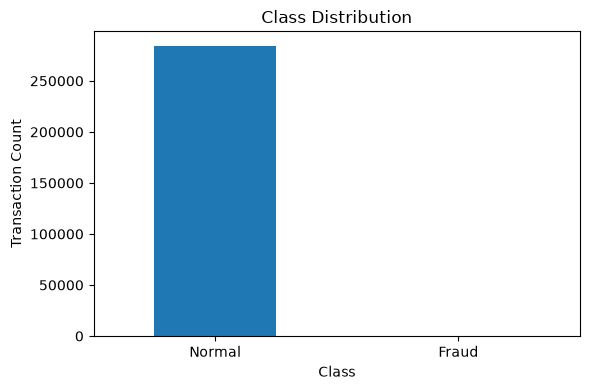

Grafik kaydedildi: ..\assets\sprint-1\class_distribution.png


In [10]:
plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Transaction Count")
plt.xticks(ticks=[0, 1], labels=["Normal", "Fraud"], rotation=0)
plt.tight_layout()

output_path = ASSETS_PATH / "class_distribution.png"
plt.savefig(output_path, dpi=150)
plt.show()

print(f"Grafik kaydedildi: {output_path}")

## 5. Amount Analizi

In [11]:
amount_summary = df.groupby(target_col)["Amount"].describe()
amount_summary.index = ["Normal Transaction", "Fraud Transaction"]

display(amount_summary)

,count,mean,std,min,25%,50%,75%,max
Normal Transaction,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
Fraud Transaction,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


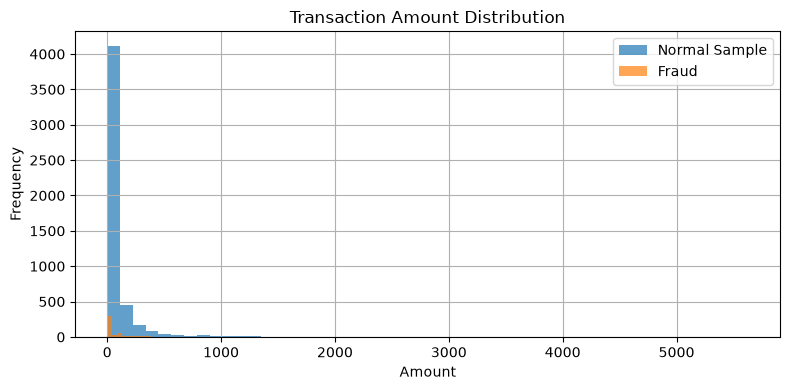

Grafik kaydedildi: ..\assets\sprint-1\amount_distribution.png


In [12]:
plt.figure(figsize=(8, 4))

normal_amount_sample = df[df[target_col] == 0]["Amount"].sample(
    min(5000, (df[target_col] == 0).sum()),
    random_state=42
)

fraud_amount = df[df[target_col] == 1]["Amount"]

normal_amount_sample.hist(bins=50, alpha=0.7, label="Normal Sample")
fraud_amount.hist(bins=50, alpha=0.7, label="Fraud")

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()

output_path = ASSETS_PATH / "amount_distribution.png"
plt.savefig(output_path, dpi=150)
plt.show()

print(f"Grafik kaydedildi: {output_path}")

## 6. Time Analizi

In [13]:
time_summary = df.groupby(target_col)["Time"].describe()
time_summary.index = ["Normal Transaction", "Fraud Transaction"]

display(time_summary)

,count,mean,std,min,25%,50%,75%,max
Normal Transaction,284315.0,94838.202258,47484.015786,0.0,54230.0,84711.0,139333.0,172792.0
Fraud Transaction,492.0,80746.806911,47835.365138,406.0,41241.5,75568.5,128483.0,170348.0


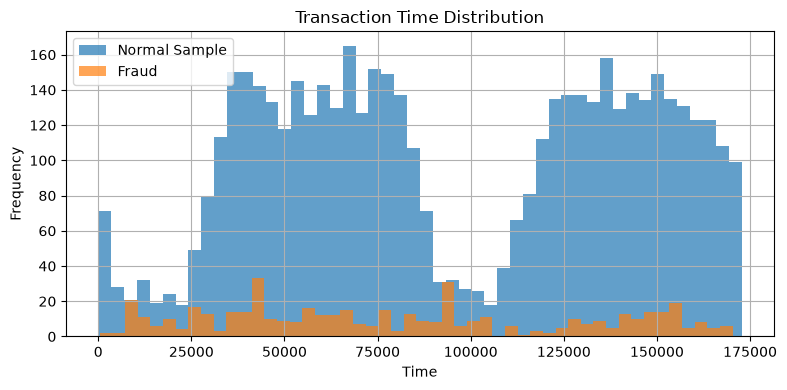

Grafik kaydedildi: ..\assets\sprint-1\time_distribution.png


In [14]:
plt.figure(figsize=(8, 4))

normal_time_sample = df[df[target_col] == 0]["Time"].sample(
    min(5000, (df[target_col] == 0).sum()),
    random_state=42
)

fraud_time = df[df[target_col] == 1]["Time"]

normal_time_sample.hist(bins=50, alpha=0.7, label="Normal Sample")
fraud_time.hist(bins=50, alpha=0.7, label="Fraud")

plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()

output_path = ASSETS_PATH / "time_distribution.png"
plt.savefig(output_path, dpi=150)
plt.show()

print(f"Grafik kaydedildi: {output_path}")

## 7. Feature / Target Ayrımı

In [15]:
X = df.drop(columns=[target_col])
y = df[target_col]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

print("\nTarget dağılımı:")
print(y.value_counts())

X shape: (284807, 30)
y shape: (284807,)

Target dağılımı:
Class
0    284315
1       492
Name: count, dtype: int64


## 8. Sprint 1 EDA Özeti

In [16]:
eda_summary = f"""
EcoShield AI - Sprint 1 EDA Summary

Dataset shape: {df.shape}
Normal transactions: {normal_count}
Fraud transactions: {fraud_count}
Fraud ratio: {fraud_count / len(df) * 100:.4f}%
Missing value columns: {len(missing_values)}
Duplicate rows: {duplicate_count}
Imbalance ratio: {imbalance_ratio:.2f}

Initial observations:
- Dataset is highly imbalanced.
- Accuracy alone is not sufficient for model evaluation.
- Recall, precision, F1-score, ROC-AUC and PR-AUC should be used.
- Class imbalance techniques such as class_weight, SMOTE and threshold tuning should be tested in later sprints.
"""

print(eda_summary)

summary_path = ASSETS_PATH / "eda_summary.txt"
with open(summary_path, "w", encoding="utf-8") as f:
    f.write(eda_summary)

print(f"EDA özeti kaydedildi: {summary_path}")


EcoShield AI - Sprint 1 EDA Summary

Dataset shape: (284807, 31)
Normal transactions: 284315
Fraud transactions: 492
Fraud ratio: 0.1727%
Missing value columns: 0
Duplicate rows: 1081
Imbalance ratio: 577.88

Initial observations:
- Dataset is highly imbalanced.
- Accuracy alone is not sufficient for model evaluation.
- Recall, precision, F1-score, ROC-AUC and PR-AUC should be used.
- Class imbalance techniques such as class_weight, SMOTE and threshold tuning should be tested in later sprints.

EDA özeti kaydedildi: ..\assets\sprint-1\eda_summary.txt


## 9. Oluşturulan Sprint 1 Çıktıları

Bu notebook çalıştırıldığında aşağıdaki dosyalar oluşmalıdır:

```text
assets/sprint-1/class_distribution.png
assets/sprint-1/amount_distribution.png
assets/sprint-1/time_distribution.png
assets/sprint-1/eda_summary.txt
```

In [17]:
print("Oluşturulan Sprint 1 çıktı dosyaları:")

for file in sorted(ASSETS_PATH.glob("*")):
    print(file)

Oluşturulan Sprint 1 çıktı dosyaları:
..\assets\sprint-1\amount_distribution.png
..\assets\sprint-1\class_distribution.png
..\assets\sprint-1\eda_summary.txt
..\assets\sprint-1\time_distribution.png
